In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
def demoRlsImplEqual():
  np.random.seed(42)

  # -----------------------------
  # Problem setup
  # -----------------------------
  N = 2000
  n_coef = 4

  # true system (complex)
  w_true = np.array([0.5+0.2j, -0.3+0.1j, 0.2-0.4j, 0.1+0.05j], dtype=np.complex64)

  # input signal
  x = (np.random.randn(N) + 1j*np.random.randn(N)).astype(np.complex64)

  # desired signal
  x_pad = np.pad(x, (n_coef-1, 0))
  d = np.zeros(N, dtype=np.complex64)

  for k in range(N):
    reg = x_pad[k:k+n_coef][::-1]
    d[k] = np.vdot(w_true, reg)

  # add small noise
  noise = 0.01*(np.random.randn(N) + 1j*np.random.randn(N))
  d += noise.astype(np.complex64)

  # -----------------------------
  # Instantiate both filters
  # -----------------------------
  rls1 =  adspfilter.RLS(mu=None, filter_order=n_coef-1, lam=0.995, delta=1e-2)
  rls2 =  adspfilter.RLSAlt(mu=None, filter_order=n_coef-1, lam=0.995, delta=1e-2)

  # -----------------------------
  # Run filters
  # -----------------------------
  y1, e1, w_hist1 = rls1(x, d, train=True)
  y2, e2, w_hist2 = rls2(x, d, train=True)

  # -----------------------------
  # Compare final weights
  # -----------------------------
  print("\n=== FINAL WEIGHTS ===")
  print("True w:     ", w_true)
  print("RLS w:      ", rls1.w)
  print("RLSAlt w:   ", rls2.w)

  # difference
  diff = np.linalg.norm(rls1.w - rls2.w)
  print("\n||RLS - RLSAlt|| =", diff)

  # -----------------------------
  # MSE convergence
  # -----------------------------
  mse1 = np.abs(e1)**2
  mse2 = np.abs(e2)**2

  # smooth
  win = 50
  mse1_s = np.convolve(mse1, np.ones(win)/win, mode='valid')
  mse2_s = np.convolve(mse2, np.ones(win)/win, mode='valid')

  # -----------------------------
  # Weight error norm
  # -----------------------------
  err_w1 = np.linalg.norm(w_hist1 - w_true, axis=1)
  err_w2 = np.linalg.norm(w_hist2 - w_true, axis=1)

  # -----------------------------
  # Plots
  # -----------------------------
  plt.figure(figsize=(12,5))

  plt.subplot(1,2,1)
  plt.plot(mse1_s, label="RLS")
  plt.plot(mse2_s, '--', label="RLSAlt")
  plt.title("MSE convergence")
  plt.yscale("log")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(err_w1, label="RLS")
  plt.plot(err_w2, '--', label="RLSAlt")
  plt.title("Weight error norm")
  plt.yscale("log")
  plt.legend()

  plt.tight_layout()
  plt.show()

  # -----------------------------
  # Assertion test
  # -----------------------------
  assert diff < 1e-3, "RLS and RLSAlt diverged!"

  print("\nPASS: Both implementations match ✔")



=== FINAL WEIGHTS ===
True w:      [ 0.5+0.2j  -0.3+0.1j   0.2-0.4j   0.1+0.05j]
RLS w:       [ 0.5001893 +0.2002083j  -0.29988524+0.10030609j  0.20047465-0.39920953j
  0.09950695+0.05030479j]
RLSAlt w:    [ 0.5002391 +0.20036294j -0.2998387 +0.10032291j  0.20016018-0.3990903j
  0.09953462+0.05061879j]

||RLS - RLSAlt|| = 0.0004912321


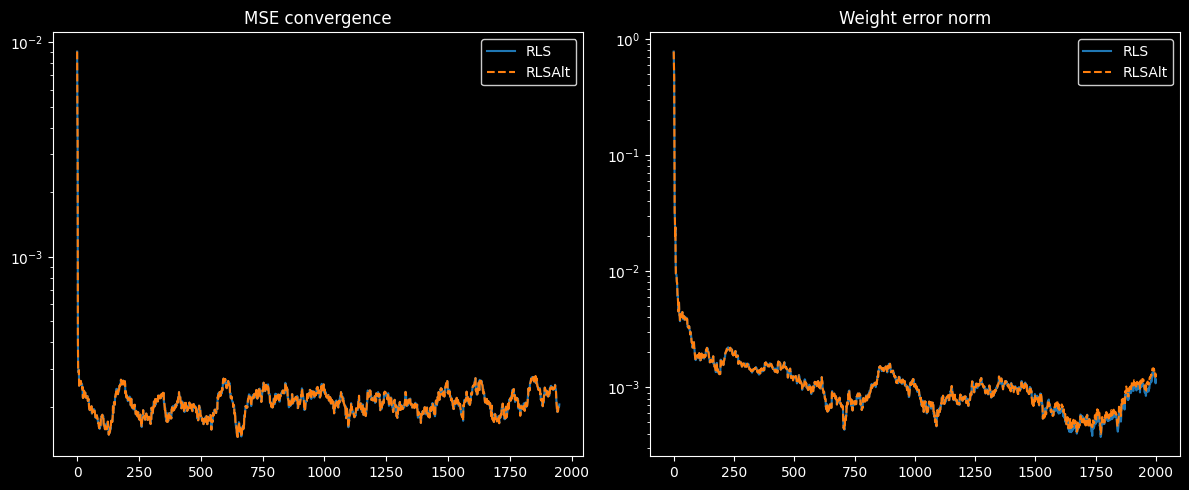


PASS: Both implementations match ✔


In [3]:
demoRlsImplEqual()

In [4]:
np.random.seed(1)

order = 3
n = 600
lam = 0.99
delta = 0.5

w0 = np.array([0.8, -0.4, 0.25, 0.1], dtype=np.complex64)
x = np.random.randn(n).astype(np.float32)

xpad = np.concatenate([np.zeros(order, dtype=np.float32), x])
d = np.zeros(n, dtype=np.complex64)
for k in range(n):
    reg = xpad[k:k+order+1][::-1].astype(np.complex64)
    d[k] = np.vdot(w0, reg)

alt = adspfilter.RLSAlt(filter_order=order, lam=lam, delta=delta)
y_alt, e_alt, w_hist_alt = alt(x, d, train=True)

qalt = adspfilter.QuantizedRLSAlt(
    filter_order=order,
    lam=lam,
    delta=delta,
    q_total_bits=20,
    q_frac_bits=12,
)
out_q = qalt(x, d, train=True)

print("w0        =", w0)
print("w_alt     =", alt.w)
print("w_qalt    =", qalt.w)
print("max |alt-qalt| =", np.max(np.abs(alt.w - qalt.w)))
print("tail RMS e_alt  =", np.sqrt(np.mean(np.abs(e_alt[-100:])**2)))
print("tail RMS e_qalt =", np.sqrt(np.mean(np.abs(out_q['e'][-100:])**2)))
print("tail RMS eps_qalt =", np.sqrt(np.mean(np.abs(out_q['eps'][-100:])**2)))

w0        = [ 0.8 +0.j -0.4 +0.j  0.25+0.j  0.1 +0.j]
w_alt     = [ 0.79999137+0.j -0.3999953 +0.j  0.24999799+0.j  0.09999844+0.j]
w_qalt    = [ 0.79956055+0.j -0.3996582 +0.j  0.24926758+0.j  0.09936523+0.j]
max |alt-qalt| = 0.0007304102
tail RMS e_alt  = 2.1180158e-05
tail RMS e_qalt = 0.001317681
tail RMS eps_qalt = 0.0012884057


In [5]:
h = np.array([0.9, 0.3, -0.2], dtype=np.float32)
np.random.seed(0)
N = 2000
x = np.random.randn(N).astype(np.float32)
delay = 2  # important
d = np.convolve(x, h)[:N]

# align desired to input (decision-directed style)
d_ref = np.roll(x, delay)
order = 5
lam = 0.995
delta = 0.5

# ---- float RLSAlt ----
rls = adspfilter.RLSAlt(filter_order=order, lam=lam, delta=delta)
y_rls, e_rls, _ = rls(d, d_ref, train=True)

# ---- quantized RLSAlt ----
qrls = adspfilter.QuantizedRLSAlt(
    filter_order=order,
    lam=lam,
    delta=delta,
    q_total_bits=20,
    q_frac_bits=12
)

out_q = qrls(d, d_ref, train=True)
y_q = out_q["y"]
e_q = out_q["e"]

def tail_mse(e, tail=500):
    return np.mean(np.abs(e[-tail:])**2)

print("Float RLS MSE:", tail_mse(e_rls))
print("Quant RLS MSE:", tail_mse(e_q))
print("Learned equalizer (float):", rls.w)
print("Learned equalizer (quant):", qrls.w)
h_eq_float = np.convolve(rls.w.real, h)
h_eq_quant = np.convolve(qrls.w.real, h)

print("Float combined (should ≈ delta):", h_eq_float)
print("Quant combined:", h_eq_quant)

Float RLS MSE: 0.016028114
Quant RLS MSE: 0.015990008
Learned equalizer (float): [ 7.3161013e-03+0.j -6.5613317e-04+0.j  1.1078379e+00+0.j
 -3.4991768e-01+0.j  3.2301480e-01+0.j -1.4547472e-01+0.j]
Learned equalizer (quant): [ 0.00585938+0.j  0.00146484+0.j  1.1018066 +0.j -0.34399414+0.j
  0.32055664+0.j -0.14282227+0.j]
Float combined (should ≈ delta): [ 0.00658449  0.00160431  0.99539405  0.0175567  -0.03582957  0.03596073
 -0.10824538  0.02909494]
Quant combined: [ 0.00527344  0.00307617  0.99089354  0.02065432 -0.03505862  0.0364258
 -0.10695801  0.02856445]


In [6]:
np.random.seed(0)
def mse_curve(e):
  return np.abs(e)**2

def smooth(x, win=50):
  return np.convolve(x, np.ones(win)/win, mode='same')
N = 2000
x = np.random.randn(N).astype(np.float32)
# channel
h = np.array([0.9, 0.3, -0.2], dtype=np.float32)
d = np.convolve(x, h)[:N]
delay = 2
d_ref = np.roll(x, delay)
order = 5

rls = adspfilter.RLSAlt(filter_order=order, lam=0.995, delta=0.5)
y_rls, e_rls, _ = rls(d, d_ref, train=True)

# ---- Quantized RLS ----
qrls = adspfilter.QuantizedRLSAlt(
    filter_order=order,
    lam=0.995,
    delta=0.5,
    q_total_bits=20,
    q_frac_bits=12
)
out_qrls = qrls(d, d_ref, train=True)
e_qrls = out_qrls["e"]


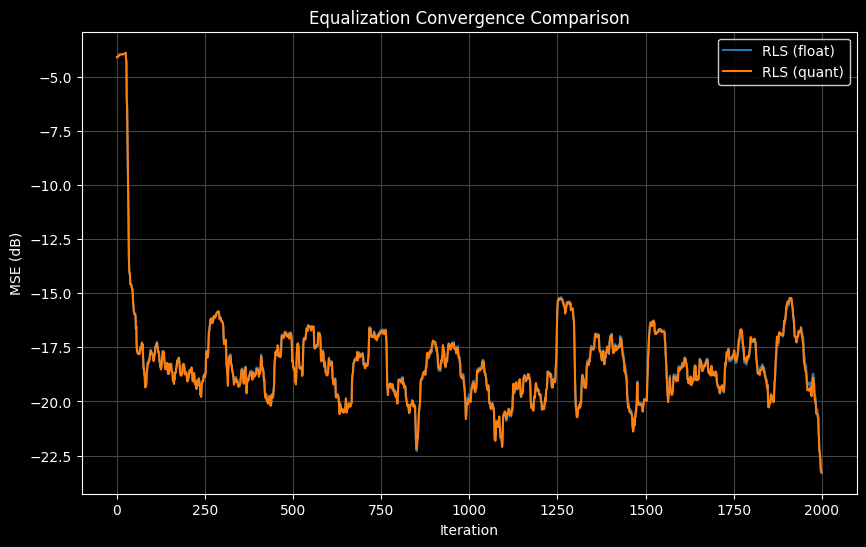

In [7]:
plt.figure(figsize=(10,6))

plt.plot(10*np.log10(smooth(mse_curve(e_rls))), label="RLS (float)")
plt.plot(10*np.log10(smooth(mse_curve(e_qrls))), label="RLS (quant)")

plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.title("Equalization Convergence Comparison")
plt.grid(True)
plt.legend()
plt.show()